### Importing Libraries

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Datasets

In [240]:
df1 = pd.read_csv('E:\\finance\\finance\\dim_customer.csv')
df1.head()

,Customer ID,Customer Name,Account Tier
0,CUST5827,Robert Reed,Premium Checking
1,CUST3747,Michael Coleman,Basic Checking
2,CUST5956,Jason Turner,Premium Checking
3,CUST4383,Brian Robbins,Basic Checking
4,CUST2239,Joseph Miller,Premium Checking


In [241]:
df2 = pd.read_csv('E:\\finance\\finance\\dim_date.csv')
df2.head()

,Date_ID,Date,Year,Quarter,Month,Month_Name,Day,Day_Of_Week,Is_Weekend
0,20230501,2023-05-01,2023,2,5,May,1,Monday,0
1,20230502,2023-05-02,2023,2,5,May,2,Tuesday,0
2,20230503,2023-05-03,2023,2,5,May,3,Wednesday,0
3,20230504,2023-05-04,2023,2,5,May,4,Thursday,0
4,20230505,2023-05-05,2023,2,5,May,5,Friday,0


In [242]:
df3 = pd.read_csv('E:\\finance\\finance\\dim_geography.csv')
df3.head()

,Geo_ID,Region,Country,Currency
0,100,Europe,France,EUR
1,101,Europe,Germany,EUR
2,102,North America,Mexico,MXN
3,103,North America,United States,USD
4,104,North America,Canada,CAD


In [243]:
df4 = pd.read_csv('E:\\finance\\finance\\dim_merchant.csv')
df4.head()

,Merchant_ID,Merchant Name,Category,Sub-Category
0,1000,Rocket Mortgage LLC,Housing,Mortgage
1,1001,Chase Mortgage,Housing,Mortgage
2,1002,Greystar Management,Housing,Rent
3,1003,Bank of America Home,Housing,Mortgage
4,1004,Equity Residential,Housing,Rent


In [244]:
df5 = pd.read_csv('E:\\finance\\finance\\fact_transactions.csv')
df5

,Transaction ID,Customer ID,Date_ID,Merchant_ID,Geo_ID,Time,Transaction Type,Payment Method,Status,Fraud Flag,Amount,Transaction Fee,Net Impact
0,TXN280248,CUST5827,20230501,1000,100,02:14:36,Debit,ACH Transfer,Completed,No,3520.00,0.00,-3520.00
1,TXN260507,CUST3747,20230501,1001,101,13:35:57,Debit,ACH Transfer,Completed,No,1800.00,0.00,-1800.00
2,TXN224097,CUST5956,20230501,1001,102,22:39:31,Debit,ACH Transfer,Completed,No,3160.00,0.00,-3160.00
3,TXN218525,CUST4383,20230502,1001,103,00:12:38,Debit,ACH Transfer,Completed,No,3180.00,0.00,-3180.00
4,TXN274606,CUST2239,20230502,1001,103,01:38:33,Debit,ACH Transfer,Completed,No,3880.00,0.00,-3880.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125270,TXN303140,CUST3402,20260527,1008,116,21:20:02,Debit,Credit Card,Pending,No,191.26,2.87,-194.13
125271,TXN252297,CUST1087,20260527,1086,102,21:40:27,Debit,Apple Pay / Wallet,Completed,No,62.99,0.94,-63.93
125272,TXN280577,CUST4265,20260527,1060,114,22:03:15,Debit,Debit Card,Completed,No,164.55,0.00,-164.55
125273,TXN217344,CUST3654,20260527,1056,102,22:16:25,Debit,Debit Card,Completed,No,12.99,0.00,-12.99


In [245]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [246]:
print("Loading Star Schema Data...")
dim_customer = pd.read_csv("dim_customer.csv")
dim_geography = pd.read_csv("dim_geography.csv")
dim_date = pd.read_csv("dim_date.csv")
dim_merchant = pd.read_csv("dim_merchant.csv")
fact_transactions = pd.read_csv("fact_transactions.csv")
print("All tables loaded successfully!")

Loading Star Schema Data...
All tables loaded successfully!


### Information of Dataset

In [247]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    5000 non-null   object
 1   Customer Name  5000 non-null   object
 2   Account Tier   5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [248]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date_ID      1102 non-null   int64 
 1   Date         1102 non-null   object
 2   Year         1102 non-null   int64 
 3   Quarter      1102 non-null   int64 
 4   Month        1102 non-null   int64 
 5   Month_Name   1102 non-null   object
 6   Day          1102 non-null   int64 
 7   Day_Of_Week  1102 non-null   object
 8   Is_Weekend   1102 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 77.6+ KB


In [249]:
df2['Date'] = pd.to_datetime(df2['Date'], format='%Y-%m-%d')

print("\nDate Columns converted:\n")
print(f"Date: {df2['Date'].dtype}")



Date Columns converted:

Date: datetime64[ns]


In [250]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date_ID      1102 non-null   int64         
 1   Date         1102 non-null   datetime64[ns]
 2   Year         1102 non-null   int64         
 3   Quarter      1102 non-null   int64         
 4   Month        1102 non-null   int64         
 5   Month_Name   1102 non-null   object        
 6   Day          1102 non-null   int64         
 7   Day_Of_Week  1102 non-null   object        
 8   Is_Weekend   1102 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 77.6+ KB


In [251]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Geo_ID    17 non-null     int64 
 1   Region    17 non-null     object
 2   Country   17 non-null     object
 3   Currency  17 non-null     object
dtypes: int64(1), object(3)
memory usage: 676.0+ bytes


In [252]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Merchant_ID    95 non-null     int64 
 1   Merchant Name  95 non-null     object
 2   Category       95 non-null     object
 3   Sub-Category   95 non-null     object
dtypes: int64(1), object(3)
memory usage: 3.1+ KB


In [253]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125275 entries, 0 to 125274
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction ID    125275 non-null  object 
 1   Customer ID       125275 non-null  object 
 2   Date_ID           125275 non-null  int64  
 3   Merchant_ID       125275 non-null  int64  
 4   Geo_ID            125275 non-null  int64  
 5   Time              125275 non-null  object 
 6   Transaction Type  125275 non-null  object 
 7   Payment Method    125275 non-null  object 
 8   Status            125275 non-null  object 
 9   Fraud Flag        125275 non-null  object 
 10  Amount            125275 non-null  float64
 11  Transaction Fee   125275 non-null  float64
 12  Net Impact        125275 non-null  float64
dtypes: float64(3), int64(3), object(7)
memory usage: 12.4+ MB


### Data Types of Data

In [254]:
df1.dtypes

Customer ID      object
Customer Name    object
Account Tier     object
dtype: object

In [255]:
df2.dtypes

Date_ID                 int64
Date           datetime64[ns]
Year                    int64
Quarter                 int64
Month                   int64
Month_Name             object
Day                     int64
Day_Of_Week            object
Is_Weekend              int64
dtype: object

In [256]:
df3.dtypes

Geo_ID       int64
Region      object
Country     object
Currency    object
dtype: object

In [257]:
df4.dtypes

Merchant_ID       int64
Merchant Name    object
Category         object
Sub-Category     object
dtype: object

In [258]:
df5.dtypes

Transaction ID       object
Customer ID          object
Date_ID               int64
Merchant_ID           int64
Geo_ID                int64
Time                 object
Transaction Type     object
Payment Method       object
Status               object
Fraud Flag           object
Amount              float64
Transaction Fee     float64
Net Impact          float64
dtype: object

In [259]:
df5.dtypes

Transaction ID       object
Customer ID          object
Date_ID               int64
Merchant_ID           int64
Geo_ID                int64
Time                 object
Transaction Type     object
Payment Method       object
Status               object
Fraud Flag           object
Amount              float64
Transaction Fee     float64
Net Impact          float64
dtype: object

In [260]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125275 entries, 0 to 125274
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction ID    125275 non-null  object 
 1   Customer ID       125275 non-null  object 
 2   Date_ID           125275 non-null  int64  
 3   Merchant_ID       125275 non-null  int64  
 4   Geo_ID            125275 non-null  int64  
 5   Time              125275 non-null  object 
 6   Transaction Type  125275 non-null  object 
 7   Payment Method    125275 non-null  object 
 8   Status            125275 non-null  object 
 9   Fraud Flag        125275 non-null  object 
 10  Amount            125275 non-null  float64
 11  Transaction Fee   125275 non-null  float64
 12  Net Impact        125275 non-null  float64
dtypes: float64(3), int64(3), object(7)
memory usage: 12.4+ MB


### Check Type

In [261]:
type(df1)
type(df2)
type(df3)
type(df4)
type(df5)

pandas.core.frame.DataFrame

### Checking Columns

In [262]:
df1.columns

Index(['Customer ID', 'Customer Name', 'Account Tier'], dtype='object')

In [263]:
df2.columns

Index(['Date_ID', 'Date', 'Year', 'Quarter', 'Month', 'Month_Name', 'Day',
       'Day_Of_Week', 'Is_Weekend'],
      dtype='object')

In [264]:
df3.columns

Index(['Geo_ID', 'Region', 'Country', 'Currency'], dtype='object')

In [265]:
df4.columns

Index(['Merchant_ID', 'Merchant Name', 'Category', 'Sub-Category'], dtype='object')

In [266]:
df5.columns

Index(['Transaction ID', 'Customer ID', 'Date_ID', 'Merchant_ID', 'Geo_ID',
       'Time', 'Transaction Type', 'Payment Method', 'Status', 'Fraud Flag',
       'Amount', 'Transaction Fee', 'Net Impact'],
      dtype='object')

### Checking Shape

In [267]:
df1.shape

(5000, 3)

In [268]:
df2.shape

(1102, 9)

In [269]:
df3.shape

(17, 4)

In [270]:
df4.shape

(95, 4)

In [271]:
df5.shape

(125275, 13)

### Describe the Dataset

In [272]:
df1.describe(include = 'object')

,Customer ID,Customer Name,Account Tier
count,5000,5000,5000
unique,5000,4831,5
top,CUST5072,Michael Brown,Basic Checking
freq,1,4,1996


In [273]:
df2.describe(include = 'object')

,Month_Name,Day_Of_Week
count,1102,1102
unique,12,7
top,May,Monday
freq,99,158


In [274]:
df3.describe(include = 'object')

,Region,Country,Currency
count,17,17,17
unique,5,17,14
top,Europe,France,EUR
freq,5,1,4


In [275]:
df4.describe(include = 'object')

,Merchant Name,Category,Sub-Category
count,95,95,95
unique,95,6,27
top,Rocket Mortgage LLC,Transportation,Clothing
freq,1,18,6


In [276]:
df5.describe(include = 'object')

,Transaction ID,Customer ID,Time,Transaction Type,Payment Method,Status,Fraud Flag
count,125275,125275,125275,125275,125275,125275,125275
unique,125275,5000,64282,2,5,3,2
top,TXN300886,CUST3843,18:56:51,Debit,ACH Transfer,Completed,No
freq,1,43,13,110272,42563,115246,124617


### Check Nulls

In [277]:
df1.isnull().sum()

Customer ID      0
Customer Name    0
Account Tier     0
dtype: int64

In [278]:
df2.isnull().sum()

Date_ID        0
Date           0
Year           0
Quarter        0
Month          0
Month_Name     0
Day            0
Day_Of_Week    0
Is_Weekend     0
dtype: int64

In [279]:
df3.isnull().sum()

Geo_ID      0
Region      0
Country     0
Currency    0
dtype: int64

In [280]:
df4.isnull().sum()

Merchant_ID      0
Merchant Name    0
Category         0
Sub-Category     0
dtype: int64

In [281]:
df5.isnull().sum()

Transaction ID      0
Customer ID         0
Date_ID             0
Merchant_ID         0
Geo_ID              0
Time                0
Transaction Type    0
Payment Method      0
Status              0
Fraud Flag          0
Amount              0
Transaction Fee     0
Net Impact          0
dtype: int64

In [282]:
print("\n=== DATA QUALITY ASSESSMENT ===")

print("\nMissing Values:\n")
missing_data = df1.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nDuplicate Rows: {df1.duplicated().sum()}")


print("\nMissing Values:\n")
missing_data = df2.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nDuplicate Rows: {df2.duplicated().sum()}")


print("\nMissing Values:\n")
missing_data = df3.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nDuplicate Rows: {df3.duplicated().sum()}")


print("\nMissing Values:\n")
missing_data = df4.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nDuplicate Rows: {df4.duplicated().sum()}")


print("\nMissing Values:\n")
missing_data = df5.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nDuplicate Rows: {df5.duplicated().sum()}")


=== DATA QUALITY ASSESSMENT ===

Missing Values:

Series([], dtype: int64)

Duplicate Rows: 0

Missing Values:

Series([], dtype: int64)

Duplicate Rows: 0

Missing Values:

Series([], dtype: int64)

Duplicate Rows: 0

Missing Values:

Series([], dtype: int64)

Duplicate Rows: 0

Missing Values:

Series([], dtype: int64)

Duplicate Rows: 0


In [283]:
negative = df5[df5['Net Impact'] < 0]
print("Total negative rows:", len(negative))
print("\nNegative billing examples:")
print(negative[['Transaction ID', 'Customer ID', 'Merchant_ID', 'Net Impact']].head(10))

Total negative rows: 110272

Negative billing examples:
  Transaction ID Customer ID  Merchant_ID  Net Impact
0      TXN280248    CUST5827         1000     -3520.0
1      TXN260507    CUST3747         1001     -1800.0
2      TXN224097    CUST5956         1001     -3160.0
3      TXN218525    CUST4383         1001     -3180.0
4      TXN274606    CUST2239         1001     -3880.0
5      TXN243043    CUST1374         1002     -2790.0
6      TXN251568    CUST4212         1001     -2890.0
7      TXN235077    CUST3752         1003     -2060.0
8      TXN268079    CUST5041         1004     -1750.0
9      TXN314532    CUST4683         1003     -1980.0


In [284]:
# Merge Fact table with Dimensions
df_eda = fact_transactions.copy()

# Bring in Customer details
df_eda = pd.merge(df_eda, dim_customer, on='Customer ID', how='left')

# Bring in Geography details
df_eda = pd.merge(df_eda, dim_geography, on='Geo_ID', how='left')

# Bring in Date details (Year, Month, Day_Of_Week, etc.)
df_eda = pd.merge(df_eda, dim_date, on='Date_ID', how='left')

# Bring in Merchant details (Category, Sub-Category)
df_eda = pd.merge(df_eda, dim_merchant, on='Merchant_ID', how='left')

print("Denormalized dataset ready for analysis. Columns available:")
print(df_eda.columns.tolist())

Denormalized dataset ready for analysis. Columns available:
['Transaction ID', 'Customer ID', 'Date_ID', 'Merchant_ID', 'Geo_ID', 'Time', 'Transaction Type', 'Payment Method', 'Status', 'Fraud Flag', 'Amount', 'Transaction Fee', 'Net Impact', 'Customer Name', 'Account Tier', 'Region', 'Country', 'Currency', 'Date', 'Year', 'Quarter', 'Month', 'Month_Name', 'Day', 'Day_Of_Week', 'Is_Weekend', 'Merchant Name', 'Category', 'Sub-Category']


### 1. Risk Management & Fraud Detection

#### Q1: Are fraudulent transactions clustered around specific merchants?


Top 5 Merchants for Fraudulent Transactions:
Merchant Name
Amazon.com Electronics      158
Apple Store                 152
Best Buy                    147
Lyft Ride                    10
Local Dealership Service      8
Name: count, dtype: int64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\1984052166.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merchant_fraud.values, y=merchant_fraud.index, palette="Reds_r")


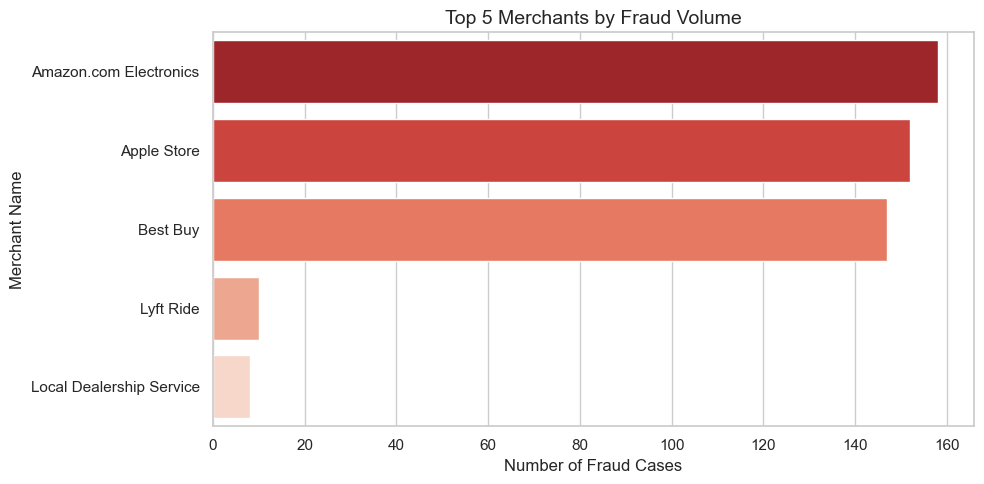

In [285]:
fraud_only = df_eda[df_eda['Fraud Flag'] == 'Yes']
merchant_fraud = fraud_only['Merchant Name'].value_counts().head(5)
print("\nTop 5 Merchants for Fraudulent Transactions:")
print(merchant_fraud)

plt.figure(figsize=(10, 5))
fraud_only = df_eda[df_eda['Fraud Flag'] == 'Yes']
merchant_fraud = fraud_only['Merchant Name'].value_counts().head(5)
sns.barplot(x=merchant_fraud.values, y=merchant_fraud.index, palette="Reds_r")
plt.title('Top 5 Merchants by Fraud Volume', fontsize=14)
plt.xlabel('Number of Fraud Cases')
plt.ylabel('Merchant Name')
plt.tight_layout()
plt.show()

#### Q2: What is the monetary threshold where fraud spikes in "Electronics"?

C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3375471114.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_bin = electronics_df.groupby('Price_Bin')['Fraud Flag'].apply(lambda x: (x == 'Yes').mean() * 100)
C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3375471114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_bin.index.astype(str), y=fraud_by_bin.values, palette="rocket")



Fraud Probability by Price Bin in Electronics (%):
Price_Bin
(0, 500]         0.187793
(500, 800]       0.068306
(800, 1000]     13.934426
(1000, 1500]    13.384159
(1500, 2000]          NaN
Name: Fraud Flag, dtype: float64


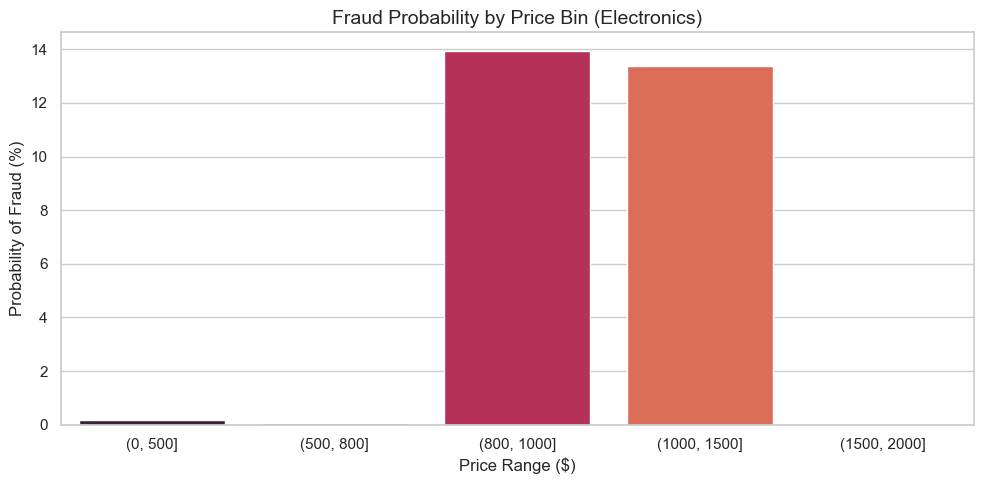

In [286]:
electronics_df = df_eda[(df_eda['Sub-Category'] == 'Electronics') & (df_eda['Transaction Type'] == 'Debit')].copy()
electronics_df['Price_Bin'] = pd.cut(electronics_df['Amount'], bins=[0, 500, 800, 1000, 1500, 2000])
fraud_by_bin = electronics_df.groupby('Price_Bin')['Fraud Flag'].apply(lambda x: (x == 'Yes').mean() * 100)

print("\nFraud Probability by Price Bin in Electronics (%):")
print(fraud_by_bin)

plt.figure(figsize=(10, 5))
electronics_df = df_eda[(df_eda['Sub-Category'] == 'Electronics') & (df_eda['Transaction Type'] == 'Debit')].copy()
electronics_df['Price_Bin'] = pd.cut(electronics_df['Amount'], bins=[0, 500, 800, 1000, 1500, 2000])
fraud_by_bin = electronics_df.groupby('Price_Bin', observed=False)['Fraud Flag'].apply(lambda x: (x == 'Yes').mean() * 100)
sns.barplot(x=fraud_by_bin.index.astype(str), y=fraud_by_bin.values, palette="rocket")
plt.title('Fraud Probability by Price Bin (Electronics)', fontsize=14)
plt.xlabel('Price Range ($)')
plt.ylabel('Probability of Fraud (%)')
plt.tight_layout()
plt.show()

#### Q3: Do "Failed" statuses correlate with "Fraud" flags?


Fraud Rate by Transaction Status (%):
Fraud Flag      No   Yes
Status                  
Completed    99.43  0.57
Failed      100.00  0.00
Pending     100.00  0.00


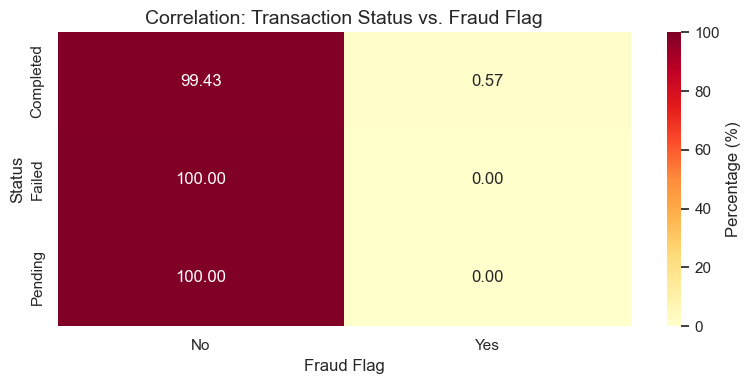

In [287]:
# Note: Based on our synthetic generation logic, fraud was only applied to "Completed" transactions. 
# This code shows how you would verify that relationship in real life.
status_fraud_crosstab = pd.crosstab(df_eda['Status'], df_eda['Fraud Flag'], normalize='index') * 100
print("\nFraud Rate by Transaction Status (%):")
print(status_fraud_crosstab.round(2))

plt.figure(figsize=(8, 4))
status_fraud_crosstab = pd.crosstab(df_eda['Status'], df_eda['Fraud Flag'], normalize='index') * 100
sns.heatmap(status_fraud_crosstab, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Percentage (%)'})
plt.title('Correlation: Transaction Status vs. Fraud Flag', fontsize=14)
plt.tight_layout()
plt.show()

### 2. Customer Segmentation & Profitability

#### Q1: Average monthly spending footprint by Account Tier


Average Monthly Spend per Customer by Tier ($):
Account Tier
Premium Checking    621.48
Student Account     614.40
Basic Checking      614.08
Business Elite      592.62
Private Wealth      589.21
Name: Amount, dtype: float64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3459990911.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_monthly_spend.values, y=avg_monthly_spend.index, palette="Blues_r")


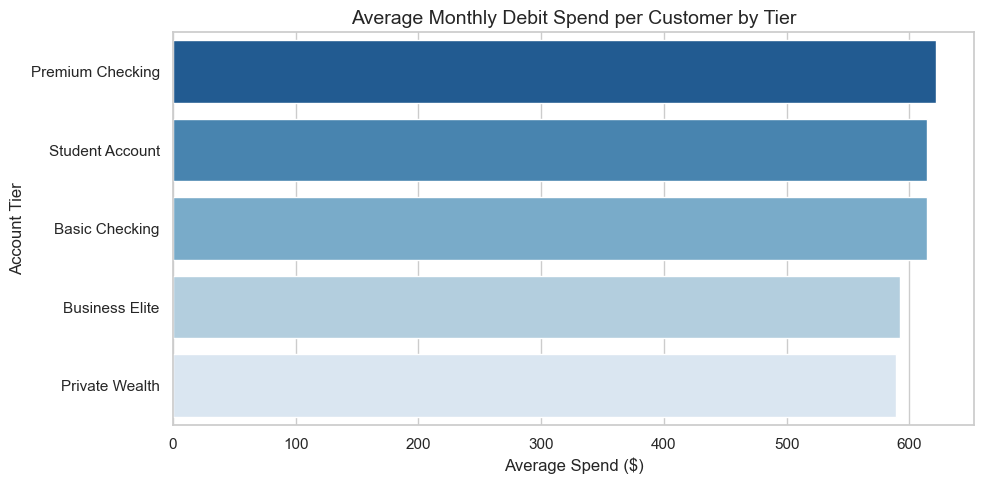

In [288]:
# Filter to Debits only, group by Tier and Month, sum the amounts, then average per tier
monthly_spend = df_eda[df_eda['Transaction Type'] == 'Debit'].groupby(['Account Tier', 'Month', 'Customer ID'])['Amount'].sum().reset_index()
avg_monthly_spend_tier = monthly_spend.groupby('Account Tier')['Amount'].mean().sort_values(ascending=False)
print("\nAverage Monthly Spend per Customer by Tier ($):")
print(avg_monthly_spend_tier.round(2))

plt.figure(figsize=(10, 5))
monthly_spend = df_eda[df_eda['Transaction Type'] == 'Debit'].groupby(['Account Tier', 'Month', 'Customer ID'])['Amount'].sum().reset_index()
avg_monthly_spend = monthly_spend.groupby('Account Tier')['Amount'].mean().sort_values(ascending=False)
sns.barplot(x=avg_monthly_spend.values, y=avg_monthly_spend.index, palette="Blues_r")
plt.title('Average Monthly Debit Spend per Customer by Tier', fontsize=14)
plt.xlabel('Average Spend ($)')
plt.ylabel('Account Tier')
plt.tight_layout()
plt.show()

#### Q2: Which account tier generates the most transaction fee revenue?


Total Fee Revenue by Account Tier ($):
Account Tier
Basic Checking      49350.27
Premium Checking    38463.61
Student Account     17498.00
Business Elite      11371.97
Private Wealth       5419.63
Name: Transaction Fee, dtype: float64


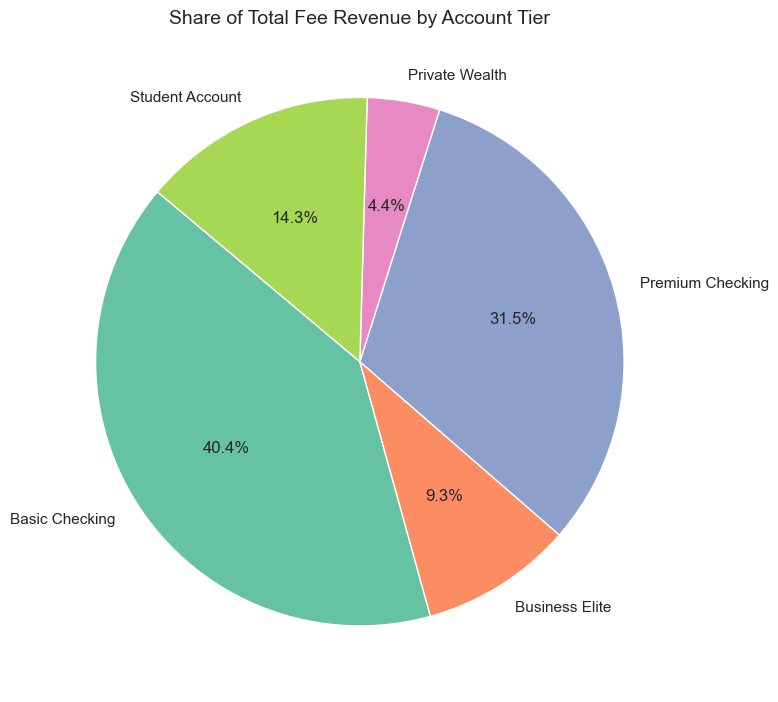

In [289]:
fee_revenue = df_eda.groupby('Account Tier')['Transaction Fee'].sum().sort_values(ascending=False)
print("\nTotal Fee Revenue by Account Tier ($):")
print(fee_revenue)

plt.figure(figsize=(8, 8))
fee_revenue = df_eda.groupby('Account Tier')['Transaction Fee'].sum()
plt.pie(fee_revenue, labels=fee_revenue.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title('Share of Total Fee Revenue by Account Tier', fontsize=14)
plt.tight_layout()
plt.show()

#### Q3: Ratio of Income to Housing expenses per account tier


Income to Housing Expense Ratio by Tier:
Category          Income_to_Housing_Ratio
Account Tier                             
Basic Checking                       1.51
Business Elite                       1.53
Premium Checking                     1.49
Private Wealth                       1.48
Student Account                      1.53


<Figure size 1000x500 with 0 Axes>

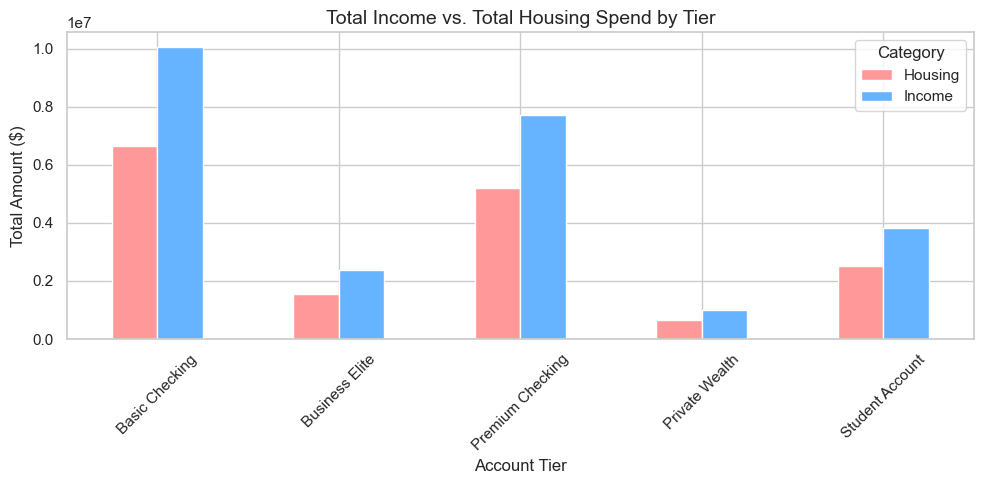

In [290]:
income_housing = df_eda[df_eda['Category'].isin(['Income', 'Housing'])].pivot_table(
    index='Account Tier', 
    columns='Category', 
    values='Amount', 
    aggfunc='sum'
)
income_housing['Income_to_Housing_Ratio'] = income_housing['Income'] / income_housing['Housing']
print("\nIncome to Housing Expense Ratio by Tier:")
print(income_housing[['Income_to_Housing_Ratio']].round(2))

plt.figure(figsize=(10, 5))
income_housing = df_eda[df_eda['Category'].isin(['Income', 'Housing'])].pivot_table(
    index='Account Tier', columns='Category', values='Amount', aggfunc='sum'
)
income_housing.plot(kind='bar', figsize=(10, 5), color=['#ff9999', '#66b3ff'])
plt.title('Total Income vs. Total Housing Spend by Tier', fontsize=14)
plt.xlabel('Account Tier')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

#### Q4: High-fee payment methods (Credit Card) usage by tier



Credit Card Usage Rate by Account Tier (%):
Account Tier
Business Elite      25.51
Basic Checking      25.49
Premium Checking    25.49
Student Account     25.25
Private Wealth      24.44
Name: Credit Card, dtype: float64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3982144133.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cc_usage.index, y=cc_usage.values, palette="magma")


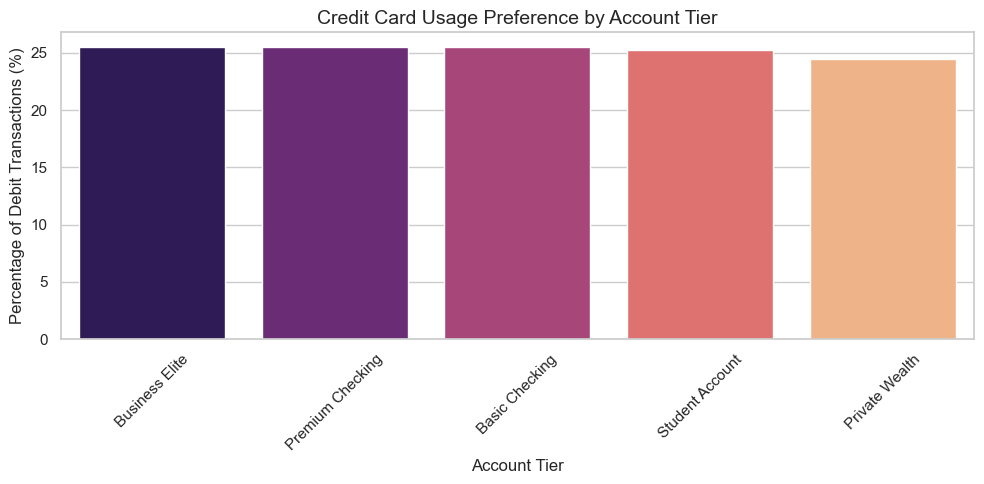

In [291]:
# What percentage of debits are made via Credit Card per tier?
debits_only = df_eda[df_eda['Transaction Type'] == 'Debit']
payment_prefs = pd.crosstab(debits_only['Account Tier'], debits_only['Payment Method'], normalize='index') * 100
print("\nCredit Card Usage Rate by Account Tier (%):")
print(payment_prefs['Credit Card'].round(2).sort_values(ascending=False))

plt.figure(figsize=(10, 5))
debits_only = df_eda[df_eda['Transaction Type'] == 'Debit']
payment_prefs = pd.crosstab(debits_only['Account Tier'], debits_only['Payment Method'], normalize='index') * 100
cc_usage = payment_prefs['Credit Card'].sort_values(ascending=False)
sns.barplot(x=cc_usage.index, y=cc_usage.values, palette="magma")
plt.title('Credit Card Usage Preference by Account Tier', fontsize=14)
plt.xlabel('Account Tier')
plt.ylabel('Percentage of Debit Transactions (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Temporal & Behavioral Economics

#### Q1: Do Entertainment/Shopping spike on weekends?


Average Spend: Weekday vs Weekend ($):
               Weekday_Avg  Weekend_Avg
Category                               
Entertainment        85.81        88.48
Shopping            257.43       259.43


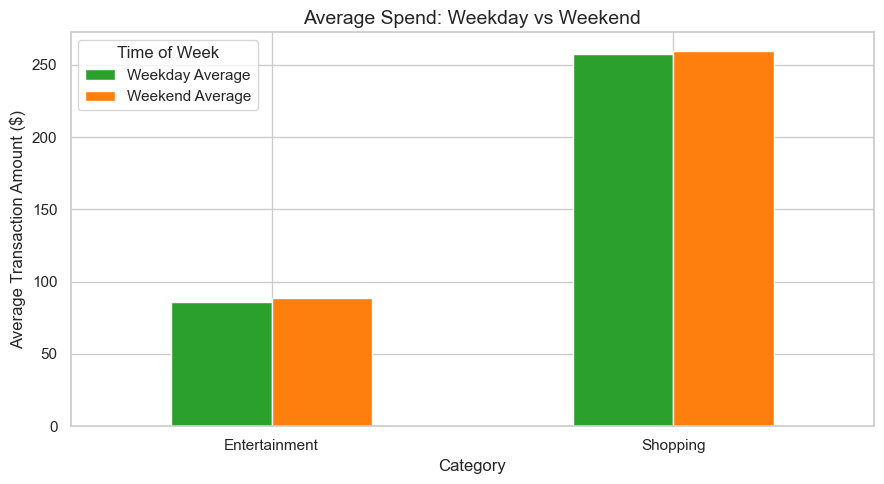

In [292]:
weekend_behavior = df_eda[df_eda['Category'].isin(['Entertainment', 'Shopping'])].groupby(
    ['Category', 'Is_Weekend']
)['Amount'].mean().unstack()
weekend_behavior.columns = ['Weekday_Avg', 'Weekend_Avg']
print("\nAverage Spend: Weekday vs Weekend ($):")
print(weekend_behavior.round(2))

weekend_behavior = df_eda[df_eda['Category'].isin(['Entertainment', 'Shopping'])].groupby(
    ['Category', 'Is_Weekend']
)['Amount'].mean().unstack()
weekend_behavior.columns = ['Weekday Average', 'Weekend Average']

weekend_behavior.plot(kind='bar', figsize=(9, 5), color=['#2ca02c', '#ff7f0e'])
plt.title('Average Spend: Weekday vs Weekend', fontsize=14)
plt.ylabel('Average Transaction Amount ($)')
plt.xticks(rotation=0)
plt.legend(title='Time of Week')
plt.tight_layout()
plt.show()

#### Q2: At what time of day do the highest volume of transactions occur?

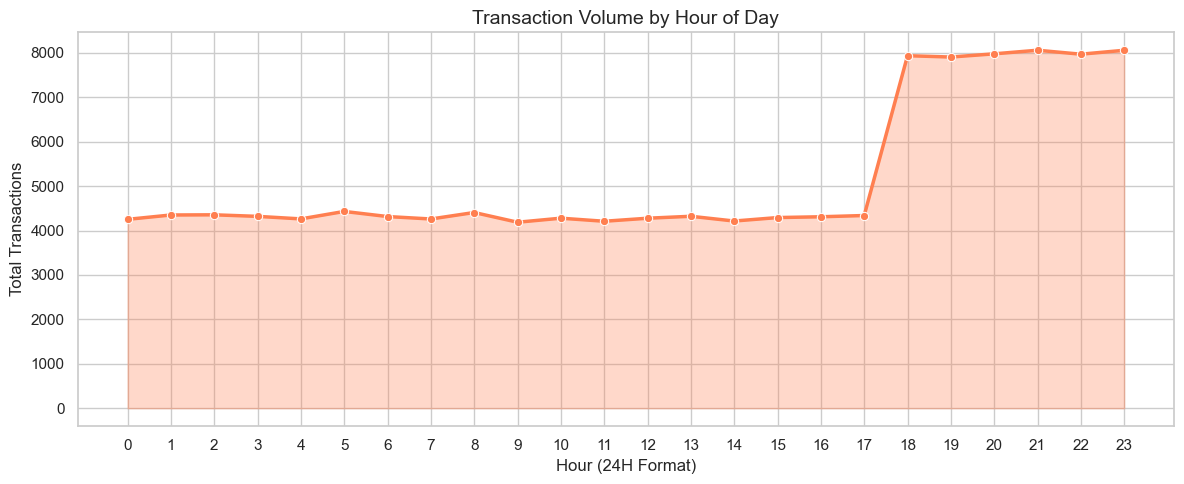

In [293]:
# Convert Time to actual datetime to extract the hour
df_eda['Hour'] = pd.to_datetime(df_eda['Time'], format='%H:%M:%S').dt.hour
hourly_volume = df_eda['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
df_eda['Hour'] = pd.to_datetime(df_eda['Time'], format='%H:%M:%S').dt.hour
hourly_volume = df_eda['Hour'].value_counts().sort_index()
sns.lineplot(x=hourly_volume.index, y=hourly_volume.values, marker="o", color='coral', linewidth=2.5)
plt.fill_between(hourly_volume.index, hourly_volume.values, alpha=0.3, color='coral')
plt.title('Transaction Volume by Hour of Day', fontsize=14)
plt.xlabel('Hour (24H Format)')
plt.ylabel('Total Transactions')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#### Q3: Are subscription payments consistently hitting on the same day?


Subscription volume spread across days of the month:
Standard Deviation of volume across days: 17.60 (Low variance means it's evenly spread)


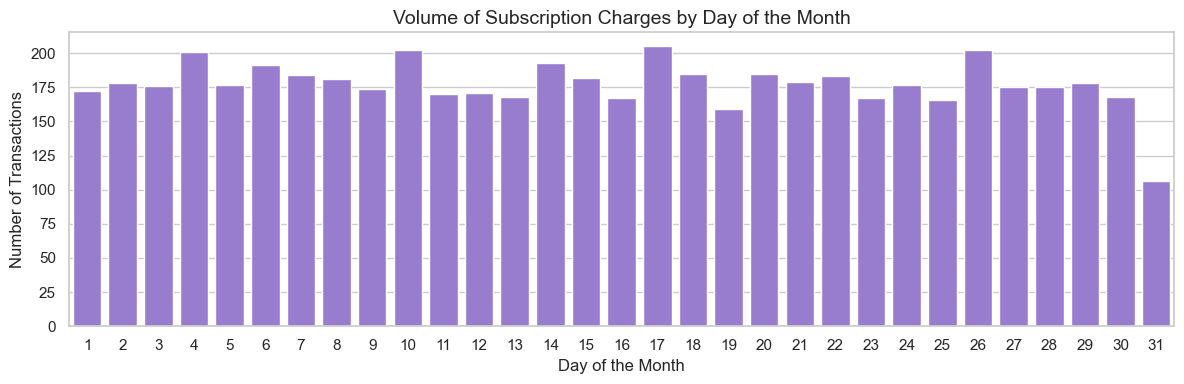

In [294]:
subscriptions = df_eda[df_eda['Sub-Category'] == 'Subscriptions']
sub_days = subscriptions['Day'].value_counts().sort_index()
print("\nSubscription volume spread across days of the month:")
print(f"Standard Deviation of volume across days: {sub_days.std():.2f} (Low variance means it's evenly spread)")

plt.figure(figsize=(12, 4))
subscriptions = df_eda[df_eda['Sub-Category'] == 'Subscriptions']
sub_days = subscriptions['Day'].value_counts().sort_index()
sns.barplot(x=sub_days.index, y=sub_days.values, color='mediumpurple')
plt.title('Volume of Subscription Charges by Day of the Month', fontsize=14)
plt.xlabel('Day of the Month')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### 4. Geographic Insights & Expansion
#### Q1: Region with the highest average transaction size for everyday expenses (Utilities, Transportation)


Average Everyday Expense Size by Region ($):
Region
North America    108.05
Asia-Pacific     106.45
Middle East      105.46
Europe           104.56
Latin America    101.15
Name: Amount, dtype: float64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3389535054.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=geo_everyday.values, y=geo_everyday.index, palette="crest")


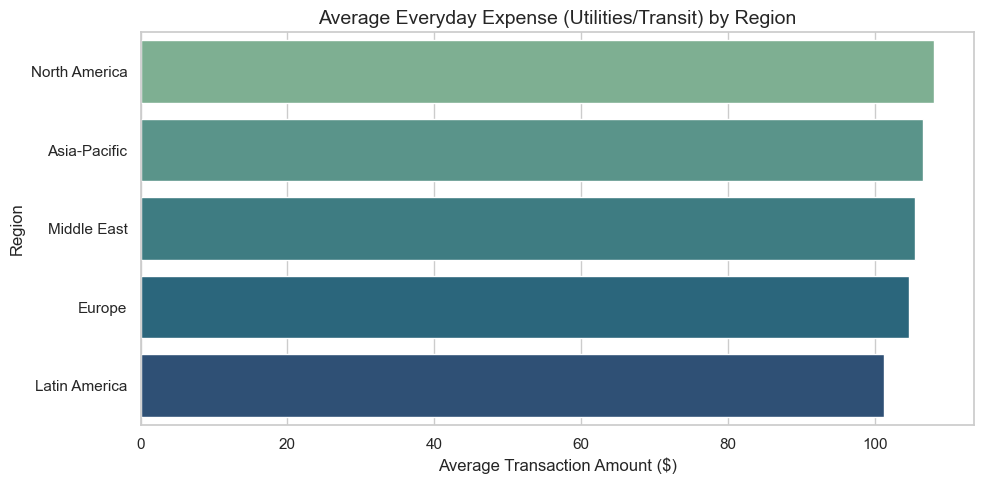

In [295]:
everyday_categories = df_eda[df_eda['Category'].isin(['Utilities', 'Transportation'])]
geo_everyday = everyday_categories.groupby('Region')['Amount'].mean().sort_values(ascending=False)
print("\nAverage Everyday Expense Size by Region ($):")
print(geo_everyday.round(2))

plt.figure(figsize=(10, 5))
everyday_categories = df_eda[df_eda['Category'].isin(['Utilities', 'Transportation'])]
geo_everyday = everyday_categories.groupby('Region')['Amount'].mean().sort_values(ascending=False)
sns.barplot(x=geo_everyday.values, y=geo_everyday.index, palette="crest")
plt.title('Average Everyday Expense (Utilities/Transit) by Region', fontsize=14)
plt.xlabel('Average Transaction Amount ($)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


#### Q2: Transaction failure rates across regions


Transaction Status Distribution by Region (%):
Status         Failed  Completed
Region                          
Latin America    3.45      91.23
North America    2.99      92.06
Europe           2.99      91.94
Asia-Pacific     2.97      92.05
Middle East      2.75      92.05


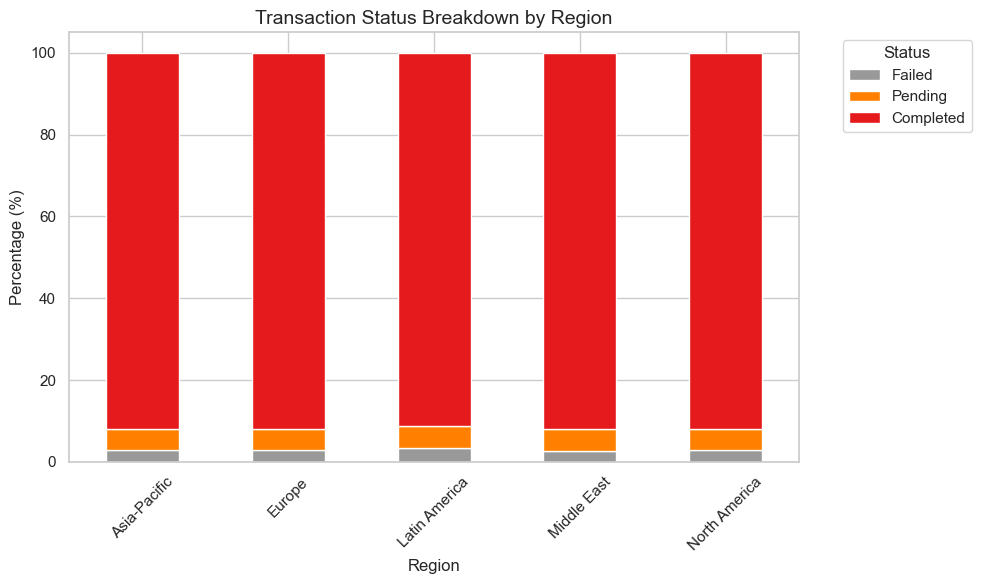

In [296]:
failure_rates = pd.crosstab(df_eda['Region'], df_eda['Status'], normalize='index') * 100
print("\nTransaction Status Distribution by Region (%):")
print(failure_rates[['Failed', 'Completed']].round(2).sort_values(by='Failed', ascending=False))

failure_rates = pd.crosstab(df_eda['Region'], df_eda['Status'], normalize='index') * 100
failure_rates[['Failed', 'Pending', 'Completed']].plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1_r')
plt.title('Transaction Status Breakdown by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q3: Total monetary volume by Currency


Total Transaction Volume by Currency ($ Equivalent for context):
Currency
CAD    11673207.49
MXN    11402203.39
USD    10484252.92
EUR     9278625.12
GBP     1958758.69
SGD     1752348.20
SAR     1433737.62
AUD     1410151.75
INR     1380316.02
AED     1358341.25
JPY     1256862.47
ARS      915052.78
COP      878156.02
BRL      760447.11
Name: Amount, dtype: float64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3587942657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=currency_volume.index, y=currency_volume.values, palette="viridis")


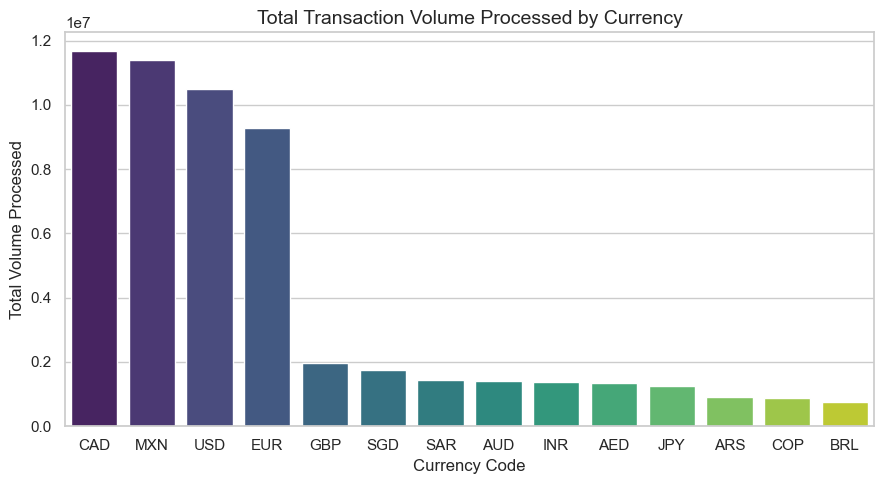

In [297]:
currency_volume = df_eda.groupby('Currency')['Amount'].sum().sort_values(ascending=False)
print("\nTotal Transaction Volume by Currency ($ Equivalent for context):")
print(currency_volume)

plt.figure(figsize=(9, 5))
currency_volume = df_eda.groupby('Currency')['Amount'].sum().sort_values(ascending=False)
sns.barplot(x=currency_volume.index, y=currency_volume.values, palette="viridis")
plt.title('Total Transaction Volume Processed by Currency', fontsize=14)
plt.xlabel('Currency Code')
plt.ylabel('Total Volume Processed')
plt.tight_layout()
plt.show()

### 5. Operational Efficiency
#### Q1: Which payment method has the highest rate of "Failed" transactions?


Failure Rate by Payment Method (%):
Payment Method
ACH Transfer          3.06
Apple Pay / Wallet    3.04
Debit Card            2.97
Bank Wire             2.92
Credit Card           2.89
Name: Failed, dtype: float64


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3182802372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fail_rates_sorted.values, y=fail_rates_sorted.index, palette="dark:salmon_r")


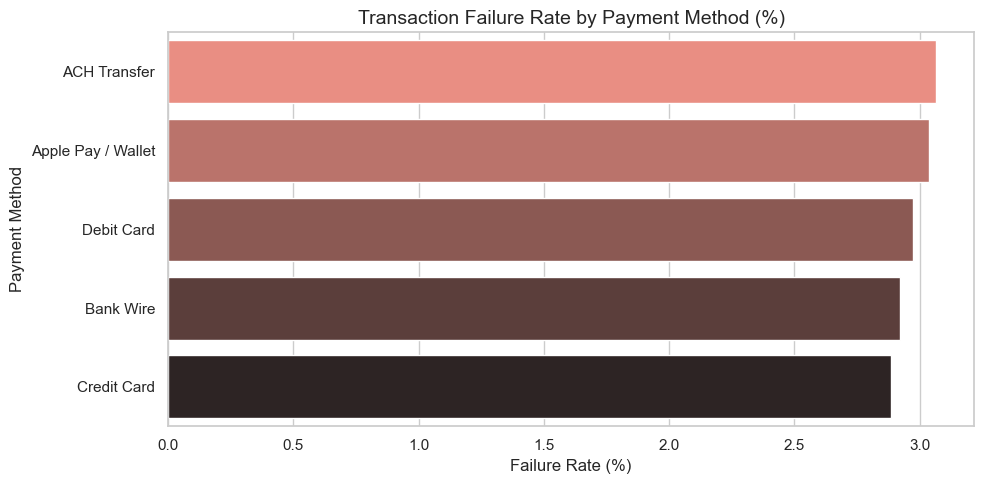

In [298]:
method_failure = pd.crosstab(df_eda['Payment Method'], df_eda['Status'], normalize='index') * 100
print("\nFailure Rate by Payment Method (%):")
print(method_failure['Failed'].sort_values(ascending=False).round(2))

plt.figure(figsize=(10, 5))
method_failure = pd.crosstab(df_eda['Payment Method'], df_eda['Status'], normalize='index') * 100
fail_rates_sorted = method_failure['Failed'].sort_values(ascending=False)
sns.barplot(x=fail_rates_sorted.values, y=fail_rates_sorted.index, palette="dark:salmon_r")
plt.title('Transaction Failure Rate by Payment Method (%)', fontsize=14)
plt.xlabel('Failure Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

#### Q2: Average fee collected per transaction type and total fee revenue


Fee Metrics by Payment Method:
                    Avg_Fee  Total_Revenue
Payment Method                            
Apple Pay / Wallet     1.87       49993.45
Credit Card            2.57       72110.03


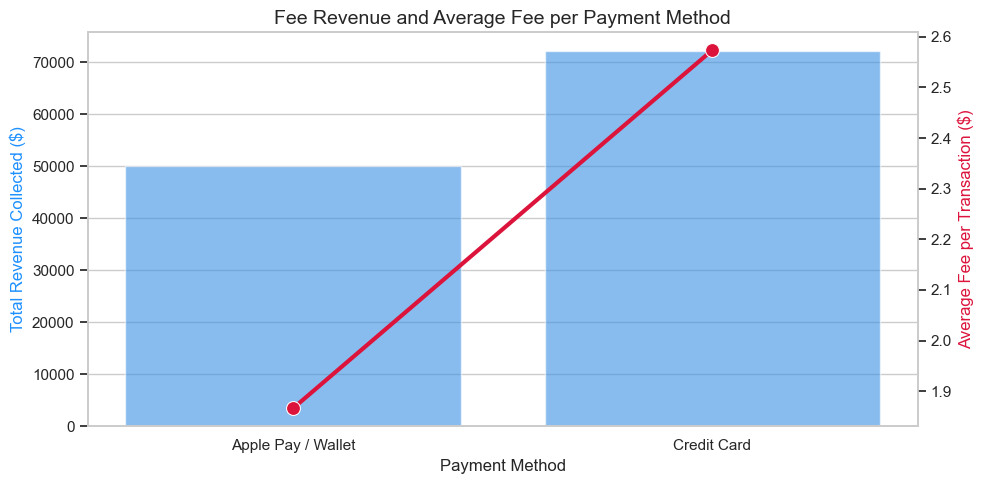

In [299]:
fee_metrics = df_eda[df_eda['Transaction Fee'] > 0].groupby('Payment Method').agg(
    Avg_Fee=('Transaction Fee', 'mean'),
    Total_Revenue=('Transaction Fee', 'sum')
)
print("\nFee Metrics by Payment Method:")
print(fee_metrics.round(2))

fee_metrics = df_eda[df_eda['Transaction Fee'] > 0].groupby('Payment Method').agg(
    Avg_Fee=('Transaction Fee', 'mean'),
    Total_Revenue=('Transaction Fee', 'sum')
)
fig, ax1 = plt.subplots(figsize=(10, 5))
# Plot Total Revenue as bars
sns.barplot(x=fee_metrics.index, y=fee_metrics['Total_Revenue'], alpha=0.6, ax=ax1, color='dodgerblue')
ax1.set_ylabel('Total Revenue Collected ($)', color='dodgerblue')
ax1.set_title('Fee Revenue and Average Fee per Payment Method', fontsize=14)
# Plot Average Fee as line on secondary axis
ax2 = ax1.twinx()
sns.lineplot(x=fee_metrics.index, y=fee_metrics['Avg_Fee'], ax=ax2, marker='o', color='crimson', linewidth=3, markersize=10)
ax2.set_ylabel('Average Fee per Transaction ($)', color='crimson')
ax2.grid(False) # Turn off grid for secondary axis to avoid clutter
plt.tight_layout()
plt.show()

#### Q3: Merchants with disproportionate volume (The 80/20 Rule check)


Top 10 Merchants by Total Processed Amount:
                       Txn_Count  Total_Amount
Merchant Name                                 
Meta Platforms               617     3433660.0
Google LLC                   613     3389880.0
Deloitte Consulting          607     3377350.0
HealthCare Corp              581     3197060.0
Amazon Corporate             572     3069640.0
State Dept of Revenue       1497     2436060.0
IRS Tax Refund              1495     2349700.0
Chase Mortgage               758     2138860.0
Rocket Mortgage LLC          730     2057230.0
Bank of America Home         691     1908800.0


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3456392191.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_merchants_volume.values, y=top_merchants_volume.index, palette="mako")


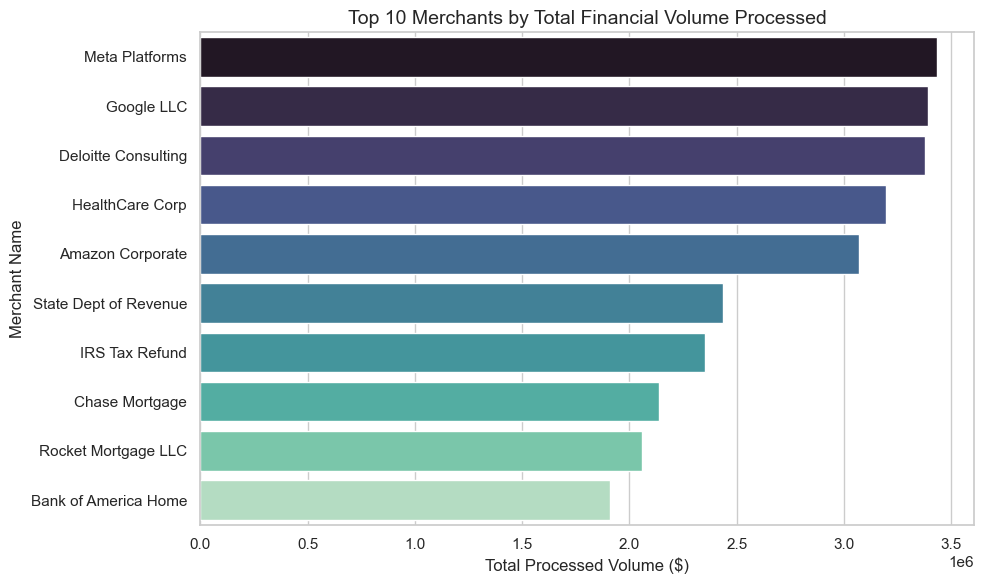

In [300]:
top_merchants_volume = df_eda.groupby('Merchant Name').agg(
    Txn_Count=('Transaction ID', 'count'),
    Total_Amount=('Amount', 'sum')
).sort_values(by='Total_Amount', ascending=False).head(10)

print("\nTop 10 Merchants by Total Processed Amount:")
print(top_merchants_volume)

plt.figure(figsize=(10, 6))
top_merchants_volume = df_eda.groupby('Merchant Name')['Amount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_merchants_volume.values, y=top_merchants_volume.index, palette="mako")
plt.title('Top 10 Merchants by Total Financial Volume Processed', fontsize=14)
plt.xlabel('Total Processed Volume ($)')
plt.ylabel('Merchant Name')
plt.tight_layout()
plt.show()

### A. dim_customer Analysis


--- Customer Dimension Analysis ---
Total Unique Customers: 5000


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\2910285121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_dist.values, y=tier_dist.index, palette="Blues_r")


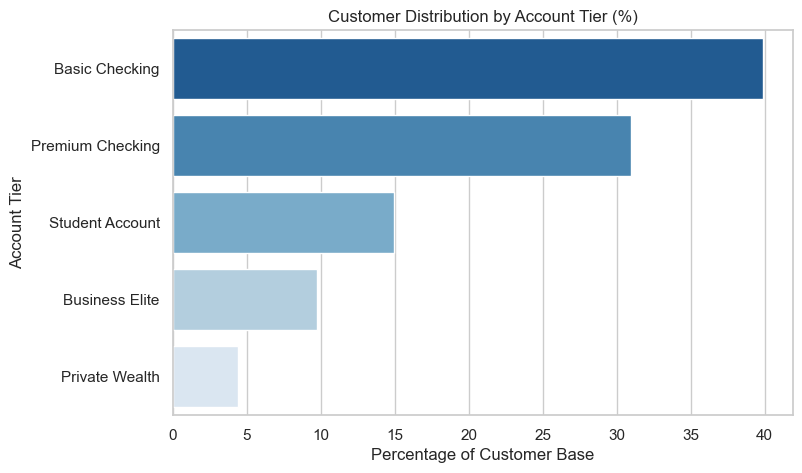

In [301]:
print("\n--- Customer Dimension Analysis ---")
print(f"Total Unique Customers: {len(dim_customer)}")

# Distribution of Account Tiers
tier_dist = dim_customer['Account Tier'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=tier_dist.values, y=tier_dist.index, palette="Blues_r")
plt.title('Customer Distribution by Account Tier (%)')
plt.xlabel('Percentage of Customer Base')
plt.ylabel('Account Tier')
plt.show()

### B. dim_geography Analysis

In [302]:
print("\n--- Geography Dimension Analysis ---")
print(f"Total Unique Geographical Profiles: {len(dim_geography)}")

# Grouping by Region to see the spread of supported countries
geo_summary = dim_geography.groupby('Region')['Country'].apply(list).reset_index()
print("\nSupported Countries per Region:")
display(geo_summary)


--- Geography Dimension Analysis ---
Total Unique Geographical Profiles: 17

Supported Countries per Region:


,Region,Country
0,Asia-Pacific,"[Singapore, Australia, India, Japan]"
1,Europe,"[France, Germany, United Kingdom, Spain, Italy]"
2,Latin America,"[Colombia, Argentina, Brazil]"
3,Middle East,"[Saudi Arabia, United Arab Emirates]"
4,North America,"[Mexico, United States, Canada]"


### C. dim_merchant Analysis


--- Merchant Dimension Analysis ---
Total Unique Merchants: 95

Merchant Catalog Breakdown:


,Category,Sub-Category,Merchant Count
0,Entertainment,Concerts,3
1,Entertainment,Gaming,5
2,Entertainment,Movies,3
3,Entertainment,Subscriptions,5
4,Housing,Home Maintenance,4
5,Housing,Mortgage,4
6,Housing,Property Tax,2
7,Housing,Rent,4
8,Income,Dividends,3
9,Income,Freelance,4


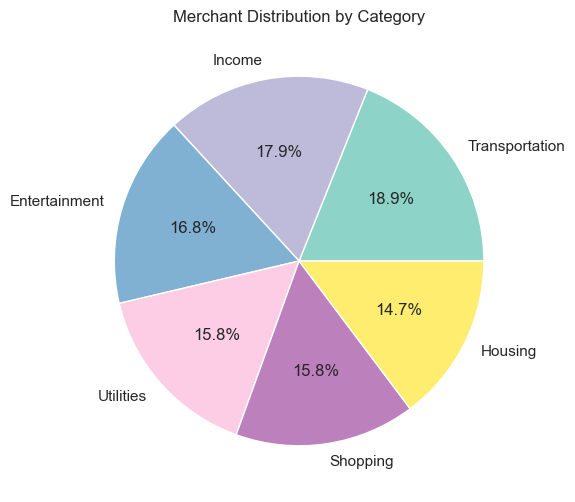

In [303]:
print("\n--- Merchant Dimension Analysis ---")
print(f"Total Unique Merchants: {len(dim_merchant)}")

# Breakdown of Sub-Categories within Main Categories
merchant_hierarchy = dim_merchant.groupby(['Category', 'Sub-Category']).size().reset_index(name='Merchant Count')
print("\nMerchant Catalog Breakdown:")
display(merchant_hierarchy)

# Visualize Main Category proportions
dim_merchant['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set3', figsize=(6, 6))
plt.title('Merchant Distribution by Category')
plt.ylabel('')
plt.show()

### D. dim_date Analysis

In [304]:
print("\n--- Date Dimension Analysis ---")
dim_date['Date'] = pd.to_datetime(dim_date['Date'])
print(f"Dataset Timeline: {dim_date['Date'].min().date()} to {dim_date['Date'].max().date()}")

# Verify weekend vs weekday distribution
day_dist = dim_date['Day_Of_Week'].value_counts()
print("\nDays tracked in calendar by Day of Week:")
print(day_dist)


--- Date Dimension Analysis ---
Dataset Timeline: 2023-05-01 to 2026-05-27

Days tracked in calendar by Day of Week:
Day_Of_Week
Monday       158
Tuesday      158
Wednesday    158
Thursday     157
Friday       157
Saturday     157
Sunday       157
Name: count, dtype: int64


### Univariate Analysis (One Variable at a Time)
#### A. Analyzing Numerical Distributions

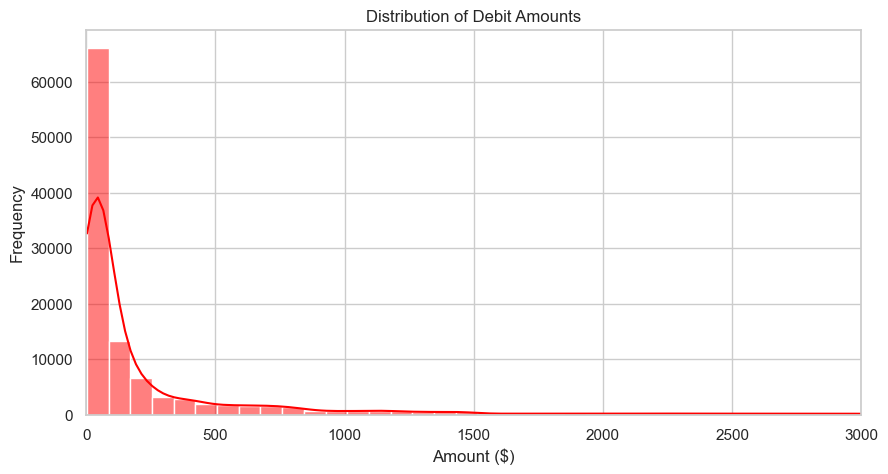

In [305]:
# Distribution of Transaction Amounts
plt.figure(figsize=(10, 5))
sns.histplot(df_eda[df_eda['Transaction Type'] == 'Debit']['Amount'], bins=50, kde=True, color='red')
plt.title('Distribution of Debit Amounts')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, 3000) # Capping X-axis to zoom in on the majority of transactions
plt.show()

#### B. Analyzing Categorical Frequencies

C:\Users\91637\AppData\Local\Temp\ipykernel_49436\3873752975.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


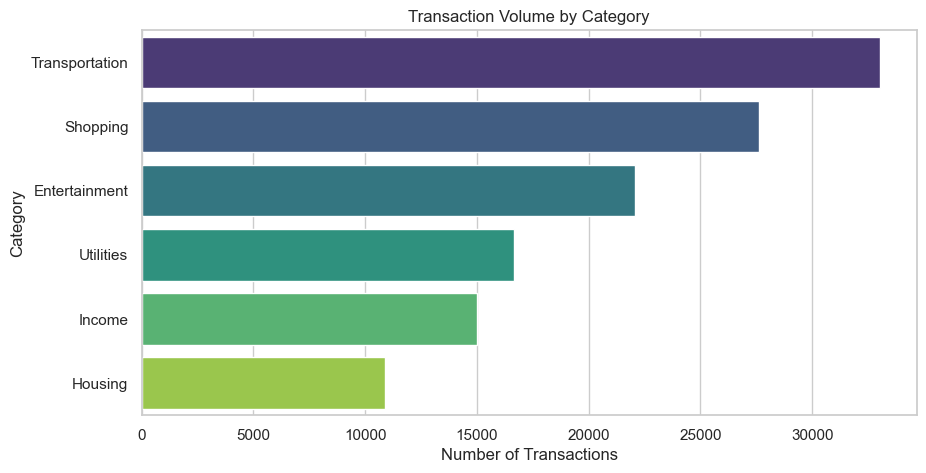

In [306]:
# Which categories drive the highest volume of transactions?
category_counts = df_eda['Category'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title('Transaction Volume by Category')
plt.xlabel('Number of Transactions')
plt.ylabel('Category')
plt.show()

### Bivariate & Multivariate Analysis (Relationships)
#### Temporal Trends (Time-Series)

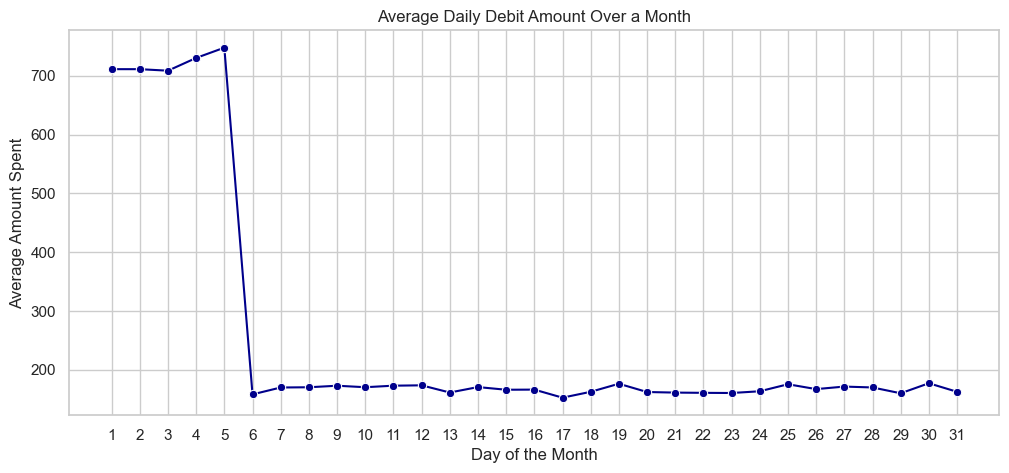

In [307]:
# Average daily spend across the month
daily_spend = df_eda[df_eda['Transaction Type'] == 'Debit'].groupby('Day')['Amount'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_spend.index, y=daily_spend.values, marker="o", color="darkblue")
plt.title('Average Daily Debit Amount Over a Month')
plt.xlabel('Day of the Month')
plt.ylabel('Average Amount Spent')
plt.xticks(range(1, 32))
plt.show()

#### B. Geographic Analysis

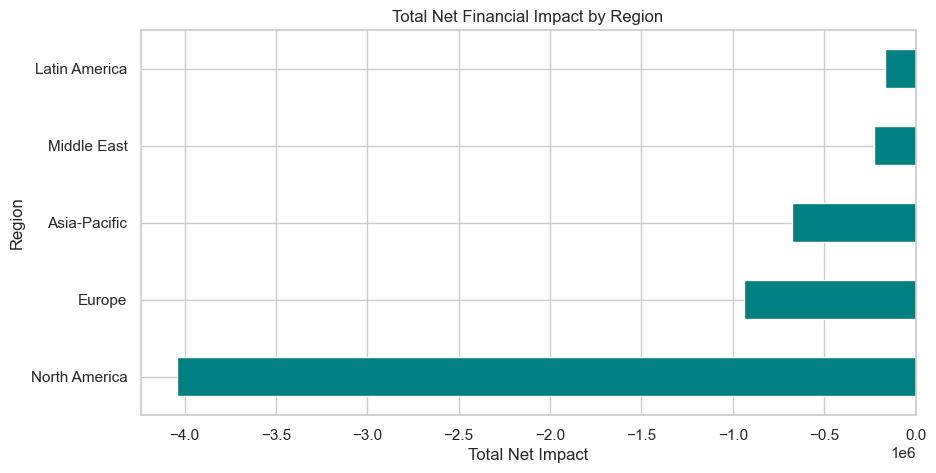

In [308]:
# Total Net Impact by Region
region_spend = df_eda.groupby('Region')['Net Impact'].sum().sort_values()

plt.figure(figsize=(10, 5))
region_spend.plot(kind='barh', color='teal')
plt.title('Total Net Financial Impact by Region')
plt.xlabel('Total Net Impact')
plt.show()

### Specialized Investigation (Fraud & Anomalies)


Overall Fraud Rate: 0.53%


C:\Users\91637\AppData\Local\Temp\ipykernel_49436\1732597000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda[df_eda['Fraud Flag'] == 'Yes'], y='Category', order=df_eda[df_eda['Fraud Flag'] == 'Yes']['Category'].value_counts().index, palette="rocket")


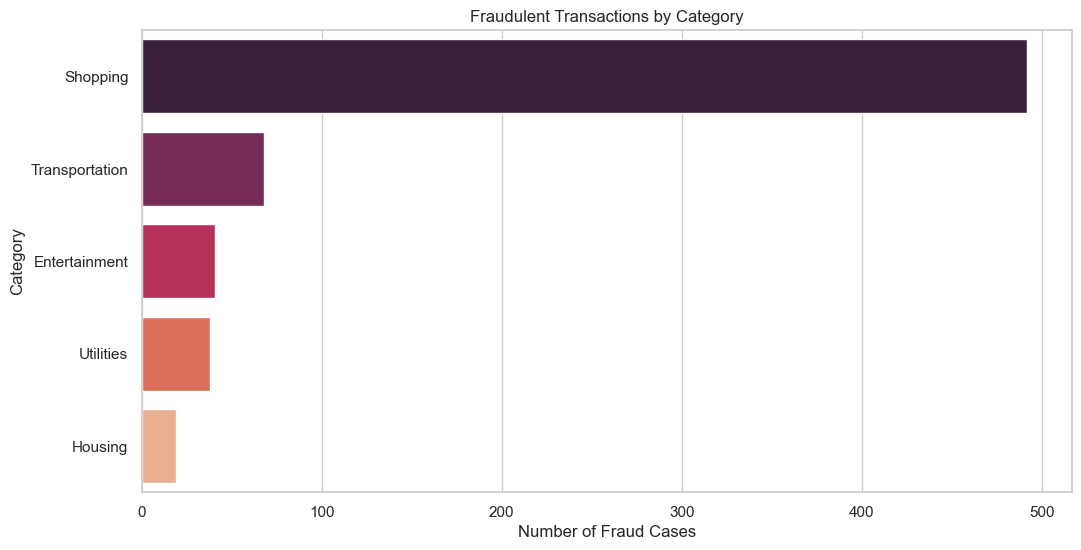

C:\Users\91637\AppData\Local\Temp\ipykernel_49436\1732597000.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['Transaction Type'] == 'Debit'], x='Fraud Flag', y='Amount', palette="Set2")


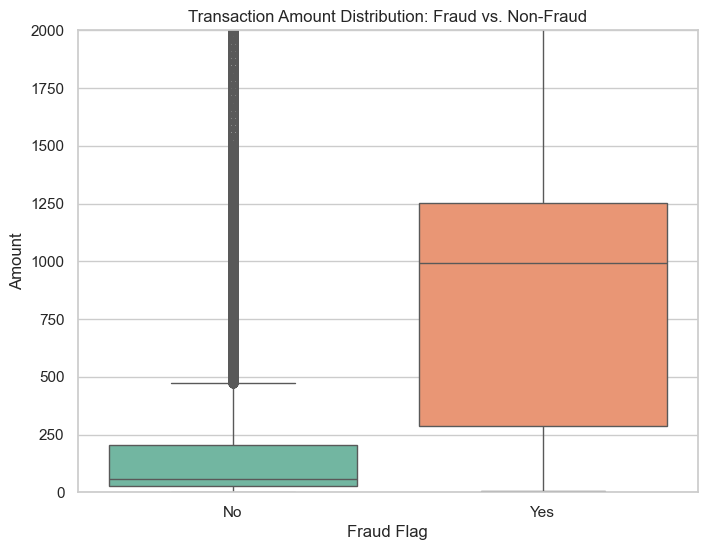

In [309]:
# 1. What is the overall fraud rate?
fraud_rate = (df_eda['Fraud Flag'] == 'Yes').mean() * 100
print(f"Overall Fraud Rate: {fraud_rate:.2f}%")

# 2. How does fraud correlate with Category?
plt.figure(figsize=(12, 6))
sns.countplot(data=df_eda[df_eda['Fraud Flag'] == 'Yes'], y='Category', order=df_eda[df_eda['Fraud Flag'] == 'Yes']['Category'].value_counts().index, palette="rocket")
plt.title('Fraudulent Transactions by Category')
plt.xlabel('Number of Fraud Cases')
plt.ylabel('Category')
plt.show()

# 3. Are fraudulent transactions usually higher values?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_eda[df_eda['Transaction Type'] == 'Debit'], x='Fraud Flag', y='Amount', palette="Set2")
plt.title('Transaction Amount Distribution: Fraud vs. Non-Fraud')
plt.ylim(0, 2000)
plt.show()

### Execution: Preparing the Data for Machine Learning

In [310]:
from sklearn.utils.class_weight import compute_class_weight

print("\n--- Step 5: Executing Next Steps & ML Preparation ---")

# We start with the fully merged 'df_eda' dataset from Step 4
df_ml = df_eda.copy()

# ==========================================
# Action 1: Feature Engineering (Velocity Metrics)
# Fraud models rely heavily on customer behavior changes. 
# Let's create a "Rolling 5-Transaction Average Spend" per customer.
# ==========================================
print("Engineering behavioral features...")

# Ensure data is sorted by time so our rolling window is mathematically accurate
df_ml = df_ml.sort_values(by=['Customer ID', 'Date', 'Time']).reset_index(drop=True)

# Calculate the rolling average of the last 5 transactions for each customer
df_ml['Rolling_5_Txn_Avg'] = df_ml.groupby('Customer ID')['Amount'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)

# Calculate the ratio of the current transaction amount against their historical average
df_ml['Amount_vs_History_Ratio'] = np.where(
    df_ml['Rolling_5_Txn_Avg'] == 0, 
    0, 
    df_ml['Amount'] / df_ml['Rolling_5_Txn_Avg']
)

print("Created features: 'Rolling_5_Txn_Avg' and 'Amount_vs_History_Ratio'")


# ==========================================
# Action 2: Target Variable Encoding
# Machine learning models need numbers, not "Yes/No" text.
# ==========================================
print("\nEncoding target variable...")
df_ml['Target_Fraud'] = (df_ml['Fraud Flag'] == 'Yes').astype(int)


# ==========================================
# Action 3: Addressing Class Imbalance
# Our EDA showed Fraud is < 1%. If we train an ML model on this directly, 
# it will just guess "Not Fraud" every time and be 99% accurate but useless.
# We must calculate Class Weights to penalize the model heavily for missing fraud.
# ==========================================
print("\nCalculating Machine Learning Class Weights...")

# Compute weights using scikit-learn
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_ml['Target_Fraud']),
    y=df_ml['Target_Fraud']
)

weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Weight assigned to Non-Fraud (0): {weight_dict[0]:.4f}")
print(f"Weight assigned to Fraud (1):     {weight_dict[1]:.2f}")
print("-> The ML algorithm will now pay massive attention to the rare fraud cases.")


# ==========================================
# Action 4: Dropping Identifiers and Exporting
# Models shouldn't train on random IDs or raw text strings.
# ==========================================
print("\nFinalizing Machine Learning dataset...")

cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Customer Name', 
    'Merchant_ID', 'Geo_ID', 'Date_ID', 'Date', 'Time', 'Fraud Flag'
]
df_ml_final = df_ml.drop(columns=cols_to_drop)

# Export the ML-ready dataset
output_file = "ML_Ready_Financial_Data.csv"
df_ml_final.to_csv(output_file, index=False)
print(f"\nSuccess! ML-ready dataset saved as '{output_file}'.")
print(f"Final dataset shape: {df_ml_final.shape}")


--- Step 5: Executing Next Steps & ML Preparation ---
Engineering behavioral features...
Created features: 'Rolling_5_Txn_Avg' and 'Amount_vs_History_Ratio'

Encoding target variable...

Calculating Machine Learning Class Weights...
Weight assigned to Non-Fraud (0): 0.5026
Weight assigned to Fraud (1):     95.19
-> The ML algorithm will now pay massive attention to the rare fraud cases.

Finalizing Machine Learning dataset...

Success! ML-ready dataset saved as 'ML_Ready_Financial_Data.csv'.
Final dataset shape: (125275, 24)
